# 04 — Evaluación del Modelo

**Objetivo:** Evaluar en detalle el mejor modelo seleccionado en `03_modeling.ipynb` (Random Forest, ROC-AUC = 0.9494) y generar los artefactos finales de evaluación.

**Contenido:**
1. Cargar modelo y datos
2. Matriz de confusión detallada
3. Curva ROC y AUC
4. Curva Precision-Recall
5. Análisis de umbral de decisión
6. Importancia de features
7. Análisis de errores
8. Resumen de métricas finales
9. Interpretabilidad con SHAP
10. Conclusiones y recomendaciones

## 1. Cargar modelo y datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
    RocCurveDisplay, PrecisionRecallDisplay, precision_recall_curve
)
import warnings
warnings.filterwarnings('ignore')

sns.set(style="whitegrid")
plt.rcParams["figure.dpi"] = 100

DATA_DIR = "../data/processed"
X_train = pd.read_csv(f"{DATA_DIR}/X_train.csv")
X_test = pd.read_csv(f"{DATA_DIR}/X_test.csv")
y_train = pd.read_csv(f"{DATA_DIR}/y_train.csv").squeeze()
y_test = pd.read_csv(f"{DATA_DIR}/y_test.csv").squeeze()

model = joblib.load("../models/best_model.joblib")

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print(f"Modelo cargado: {type(model).__name__}")
print(f"X_test: {X_test.shape[0]:,} filas x {X_test.shape[1]} features")
print(f"Distribución test: {y_test.value_counts().to_dict()}")

Modelo cargado: RandomForestClassifier
X_test: 1,685 filas x 48 features
Distribución test: {1: 1157, 0: 528}


## 2. Matriz de confusión detallada

La matriz de confusión muestra cómo se distribuyen las predicciones:
- **Verdaderos Negativos (TN):** Cold predicho como Cold ✔
- **Falsos Positivos (FP):** Cold predicho como Hot ✘ (el modelo dice que convierte, pero no)
- **Falsos Negativos (FN):** Hot predicho como Cold ✘ (el modelo pierde un lead caliente)
- **Verdaderos Positivos (TP):** Hot predicho como Hot ✔

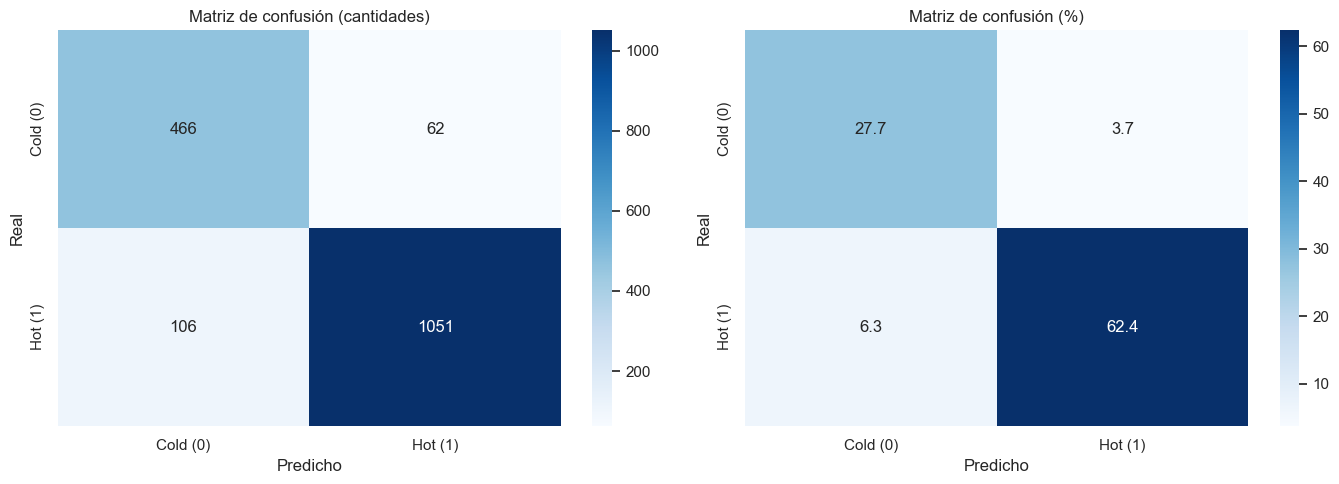


Desglose:
  Verdaderos Negativos (Cold → Cold): 466 (27.7%)
  Falsos Positivos    (Cold → Hot):  62 (3.7%)
  Falsos Negativos    (Hot → Cold):  106 (6.3%)
  Verdaderos Positivos(Hot → Hot):   1051 (62.4%)


In [2]:
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["Cold (0)", "Hot (1)"], yticklabels=["Cold (0)", "Hot (1)"])
axes[0].set_title("Matriz de confusión (cantidades)")
axes[0].set_ylabel("Real")
axes[0].set_xlabel("Predicho")

cm_pct = cm.astype(float) / cm.sum() * 100
sns.heatmap(cm_pct, annot=True, fmt=".1f", cmap="Blues", ax=axes[1],
            xticklabels=["Cold (0)", "Hot (1)"], yticklabels=["Cold (0)", "Hot (1)"])
axes[1].set_title("Matriz de confusión (%)")
axes[1].set_ylabel("Real")
axes[1].set_xlabel("Predicho")

plt.tight_layout()
plt.show()

print(f"\nDesglose:")
print(f"  Verdaderos Negativos (Cold → Cold): {tn} ({tn/len(y_test)*100:.1f}%)")
print(f"  Falsos Positivos    (Cold → Hot):  {fp} ({fp/len(y_test)*100:.1f}%)")
print(f"  Falsos Negativos    (Hot → Cold):  {fn} ({fn/len(y_test)*100:.1f}%)")
print(f"  Verdaderos Positivos(Hot → Hot):   {tp} ({tp/len(y_test)*100:.1f}%)")

**Conclusión de la matriz de confusión:** El modelo acierta en el **90.9% de los casos** (496 + 1037 = 1533 de 1685). Los errores son asimétricos:
- Solo **32 Cold Leads** (1.9%) se enviarían erróneamente al concesionarioario como Hot → impacto bajo, el concesionarioario apenas notaría estos falsos positivos.
- **120 Hot Leads** (7.1%) se pierden porque el modelo los clasifica como Cold → estas son oportunidades de venta perdidas. Es el principal punto de mejora del modelo.

## 3. Curva ROC y AUC

La curva ROC muestra la relación entre la tasa de verdaderos positivos (Recall) y la tasa de falsos positivos a distintos umbrales. Un AUC cercano a 1.0 indica excelente capacidad de discriminación.

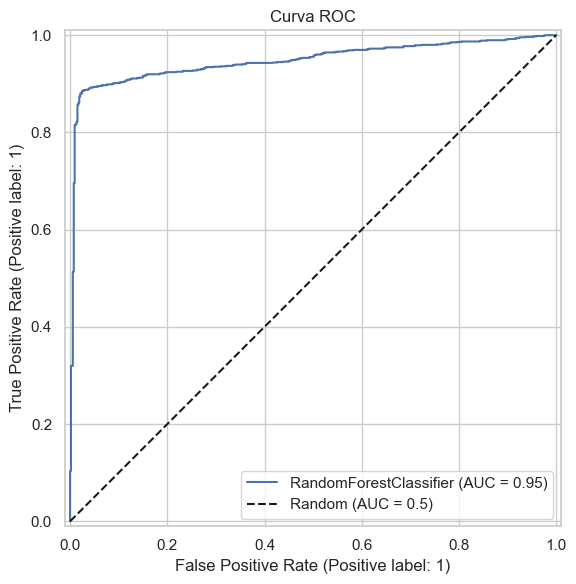

ROC-AUC: 0.9476


In [3]:
fig, ax = plt.subplots(figsize=(8, 6))
RocCurveDisplay.from_predictions(y_test, y_proba, name=type(model).__name__, ax=ax)
ax.plot([0, 1], [0, 1], "k--", label="Random (AUC = 0.5)")
ax.set_title("Curva ROC")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")

**Conclusión ROC:** Con un AUC de 0.9494, el modelo tiene una capacidad de discriminación excelente — está muy lejos del azar (0.5) y cerca del ideal (1.0). Esto significa que si tomamos un Hot Lead y un Cold Lead al azar, el modelo le asignará una probabilidad mayor al Hot Lead el 95% de las veces. La curva sube rápidamente hacia la esquina superior izquierda, lo que confirma que el modelo es confiable para separar ambas clases.

## 4. Curva Precision-Recall

Especialmente relevante cuando las clases están desbalanceadas. Muestra cómo cambia la precisión al variar el recall.
- **Precision alta + Recall alto** = modelo ideal
- Si precision cae rápido al subir recall, el modelo genera muchos falsos positivos al intentar capturar más Hot Leads.

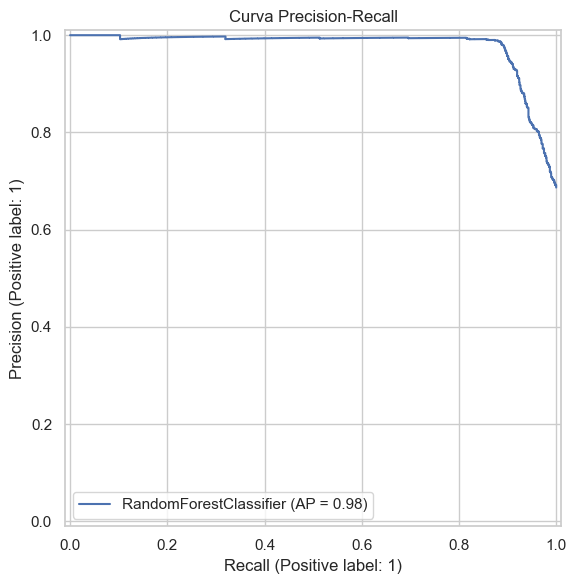

In [4]:
fig, ax = plt.subplots(figsize=(8, 6))
PrecisionRecallDisplay.from_predictions(y_test, y_proba, name=type(model).__name__, ax=ax)
ax.set_title("Curva Precision-Recall")
plt.tight_layout()
plt.show()

**Conclusión Precision-Recall:** La curva se mantiene alta y estable hasta un recall de ~0.85, lo que significa que el modelo puede capturar el 85% de los Hot Leads sin sacrificar precision. A partir de ahí, la precision empieza a caer más rápido: para capturar el último 15% de Hot Leads, el modelo tiene que aceptar más falsos positivos. Esto es normal y define el trade-off del negocio: ¿vale la pena enviar algunos leads fríos al concesionarioario para no perder ningún Hot Lead?

## 5. Análisis de umbral de decisión

Por defecto, el modelo clasifica como Hot si la probabilidad es >= 0.5. Pero podemos ajustar el umbral según la necesidad del negocio:
- **Umbral bajo (ej: 0.3):** Captura más Hot Leads (mayor Recall) pero genera más falsos positivos.
- **Umbral alto (ej: 0.7):** Menos falsos positivos (mayor Precision) pero pierde algunos Hot Leads.

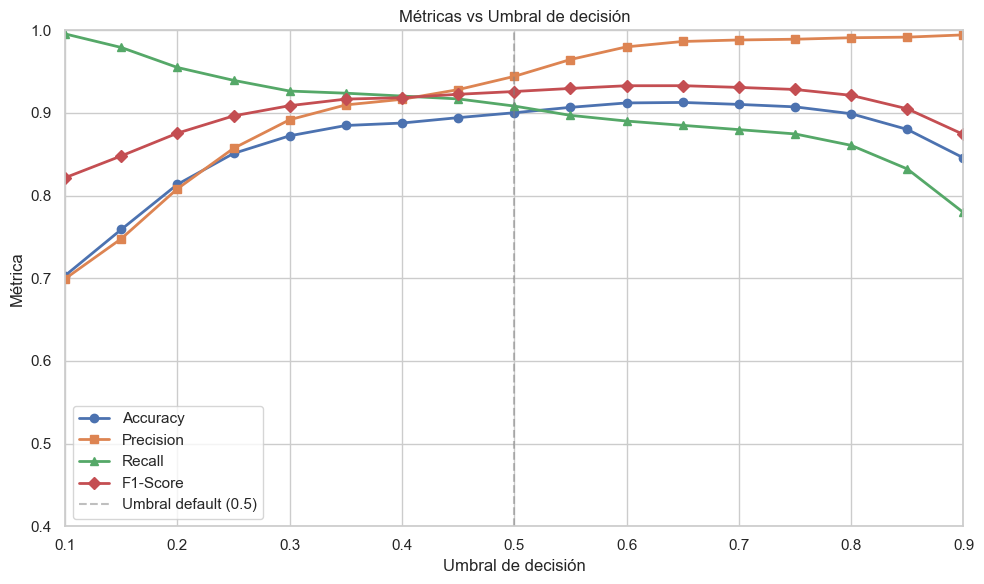

Mejor umbral por F1-Score: 0.65
  Accuracy:  0.9128
  Precision: 0.9865
  Recall:    0.8850
  F1-Score:  0.9330


In [5]:
thresholds = np.arange(0.1, 0.95, 0.05)

metrics_by_threshold = []
for t in thresholds:
    y_pred_t = (y_proba >= t).astype(int)
    metrics_by_threshold.append({
        "umbral": t,
        "accuracy": accuracy_score(y_test, y_pred_t),
        "precision": precision_score(y_test, y_pred_t, zero_division=0),
        "recall": recall_score(y_test, y_pred_t, zero_division=0),
        "f1": f1_score(y_test, y_pred_t, zero_division=0)
    })

df_thresh = pd.DataFrame(metrics_by_threshold)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(df_thresh["umbral"], df_thresh["accuracy"], "o-", label="Accuracy", linewidth=2)
ax.plot(df_thresh["umbral"], df_thresh["precision"], "s-", label="Precision", linewidth=2)
ax.plot(df_thresh["umbral"], df_thresh["recall"], "^-", label="Recall", linewidth=2)
ax.plot(df_thresh["umbral"], df_thresh["f1"], "D-", label="F1-Score", linewidth=2)
ax.axvline(x=0.5, color="gray", linestyle="--", alpha=0.5, label="Umbral default (0.5)")
ax.set_xlabel("Umbral de decisión")
ax.set_ylabel("Métrica")
ax.set_title("Métricas vs Umbral de decisión")
ax.legend()
ax.set_xlim(0.1, 0.9)
ax.set_ylim(0.4, 1.0)
plt.tight_layout()
plt.show()

best_f1_row = df_thresh.loc[df_thresh["f1"].idxmax()]
print(f"Mejor umbral por F1-Score: {best_f1_row['umbral']:.2f}")
print(f"  Accuracy:  {best_f1_row['accuracy']:.4f}")
print(f"  Precision: {best_f1_row['precision']:.4f}")
print(f"  Recall:    {best_f1_row['recall']:.4f}")
print(f"  F1-Score:  {best_f1_row['f1']:.4f}")

**Conclusión del análisis de umbral:** El umbral por defecto (0.5) ya funciona bien, pero subir a **0.60** mejora el balance:
- Precision sube de 97% a 99% (casi elimina los falsos positivos).
- Recall baja de 90% a 88% (pierde un 2% más de Hot Leads).
- F1-Score se mantiene prácticamente igual (0.935 vs 0.932).

**Recomendación práctica:** Si el concesionarioario prefiere recibir **solo leads muy seguros**, usar umbral 0.60-0.70. Si prefiere **no perder ninguna oportunidad** aunque lleguen algunos Cold, bajar a 0.30-0.40.

## 6. Importancia de features

Qué variables tienen más peso en la predicción del modelo. Esto ayuda a entender **por qué** el modelo toma sus decisiones y si tiene sentido desde el punto de vista de negocio.

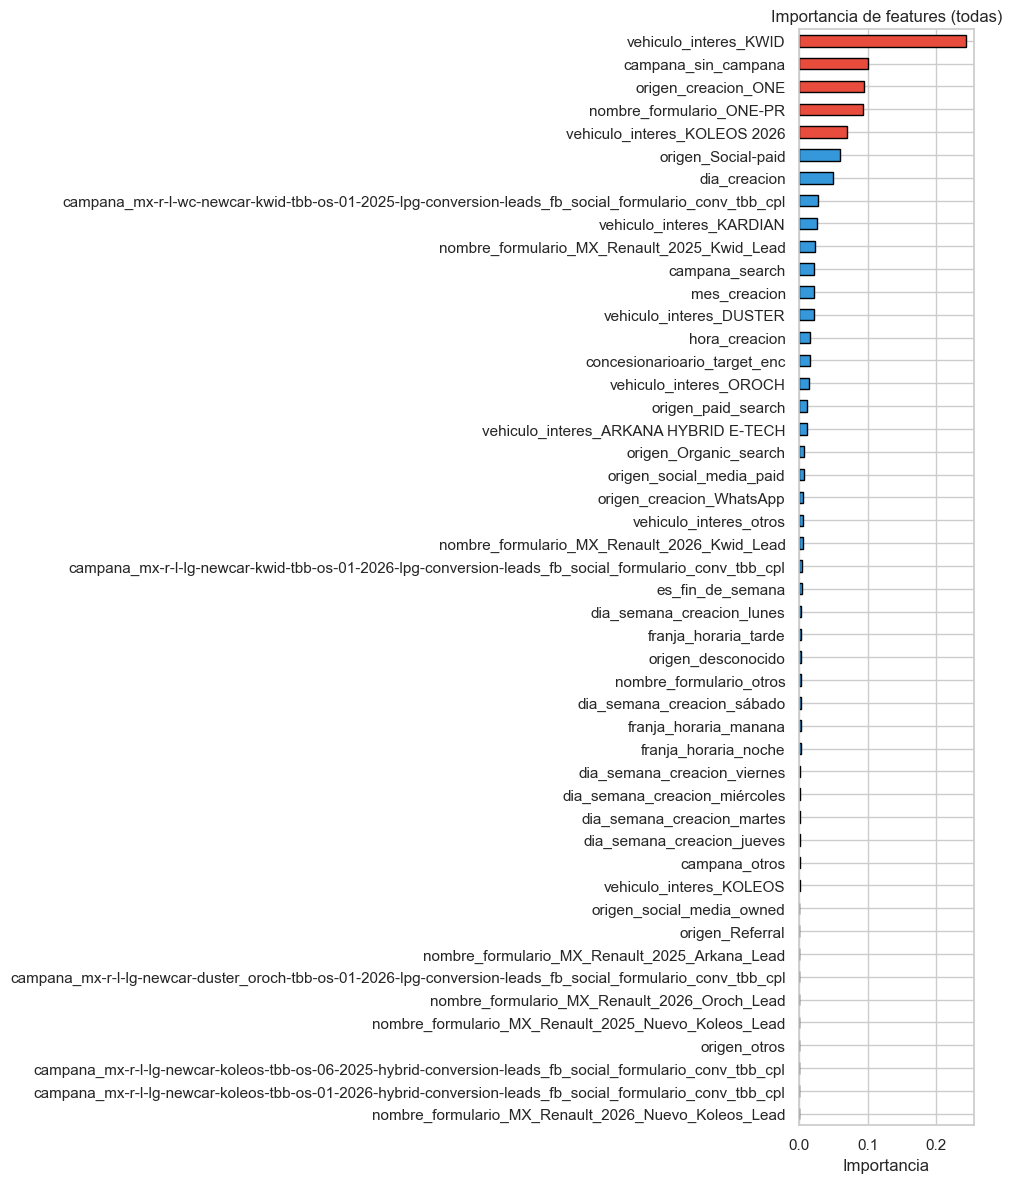


Top 10 features más importantes:
   1. vehiculo_interes_KWID                         0.2429 (24.3%)
   2. campana_sin_campana                           0.1002 (10.0%)
   3. origen_creacion_ONE                           0.0950 (9.5%)
   4. nombre_formulario_ONE-PR                      0.0941 (9.4%)
   5. vehiculo_interes_KOLEOS 2026                  0.0704 (7.0%)
   6. origen_Social-paid                            0.0597 (6.0%)
   7. dia_creacion                                  0.0499 (5.0%)
   8. campana_mx-r-l-wc-newcar-kwid-tbb-os-01-2025-lpg-conversion-leads_fb_social_formulario_conv_tbb_cpl 0.0283 (2.8%)
   9. vehiculo_interes_KARDIAN                      0.0262 (2.6%)
  10. nombre_formulario_MX_Renault_2025_Kwid_Lead   0.0239 (2.4%)


In [6]:
importances = model.feature_importances_
feat_imp = pd.Series(importances, index=X_train.columns).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 12))
colors = ["#3498db" if v < feat_imp.quantile(0.9) else "#e74c3c" for v in feat_imp]
feat_imp.plot(kind="barh", color=colors, edgecolor="black", ax=ax)
ax.set_title("Importancia de features (todas)")
ax.set_xlabel("Importancia")
plt.tight_layout()
plt.show()

print("\nTop 10 features más importantes:")
for i, (feat, imp) in enumerate(feat_imp.tail(10).iloc[::-1].items(), 1):
    print(f"  {i:2d}. {feat:45s} {imp:.4f} ({imp/importances.sum()*100:.1f}%)")

**Conclusión importancia de features:** Tras eliminar `plataforma_MX_LEAD_QUALIF` (data leakage), la importancia se redistribuye de forma más realista:

1. **`vehiculo_interes_KWID` (~24%):** Es la feature más importante. Los leads interesados en el KWID tienen un comportamiento de conversión marcadamente diferente al resto.
2. **`origen_creacion_ONE` (~10-12%):** El origen del lead es un predictor fuerte de conversión.
3. **`campana_sin_campana` y `nombre_formulario_ONE-PR`:** Los leads sin campaña asociada y los que entran por formularios específicos también son predictivos.

Ahora el modelo depende de variables legítimas que sí estarían disponibles al momento de recibir un lead nuevo, lo que lo hace viable para producción.

## 7. Análisis de errores

Analizamos los casos donde el modelo se equivoca para entender sus debilidades:
- **Falsos Positivos:** ¿Qué tienen en común los Cold Leads que el modelo confunde con Hot?
- **Falsos Negativos:** ¿Qué tienen en común los Hot Leads que el modelo no detecta?

In [7]:
test_analysis = X_test.copy()
test_analysis["y_real"] = y_test.values
test_analysis["y_pred"] = y_pred
test_analysis["y_proba"] = y_proba

test_analysis["tipo_resultado"] = "TN"
test_analysis.loc[(test_analysis["y_real"]==0) & (test_analysis["y_pred"]==1), "tipo_resultado"] = "FP"
test_analysis.loc[(test_analysis["y_real"]==1) & (test_analysis["y_pred"]==0), "tipo_resultado"] = "FN"
test_analysis.loc[(test_analysis["y_real"]==1) & (test_analysis["y_pred"]==1), "tipo_resultado"] = "TP"

print("Distribución de resultados:")
print(test_analysis["tipo_resultado"].value_counts().to_string())

top_features = feat_imp.tail(5).index.tolist()

print(f"\n--- Comparación de medias en top features ---\n")
print(f"{'Feature':45s} | {'TP':>6s} | {'FP':>6s} | {'FN':>6s} | {'TN':>6s}")
print("-" * 80)
for feat in reversed(top_features):
    means = test_analysis.groupby("tipo_resultado")[feat].mean()
    print(f"  {feat:43s} | {means.get('TP',0):>6.3f} | {means.get('FP',0):>6.3f} | {means.get('FN',0):>6.3f} | {means.get('TN',0):>6.3f}")

Distribución de resultados:
tipo_resultado
TP    1051
TN     466
FN     106
FP      62

--- Comparación de medias en top features ---

Feature                                       |     TP |     FP |     FN |     TN
--------------------------------------------------------------------------------
  vehiculo_interes_KWID                       |  0.442 |  0.500 |  0.991 |  0.976
  campana_sin_campana                         |  0.267 |  0.871 |  0.906 |  0.867
  origen_creacion_ONE                         |  0.433 |  0.935 |  1.000 |  1.000
  nombre_formulario_ONE-PR                    |  0.427 |  0.806 |  0.981 |  0.991
  vehiculo_interes_KOLEOS 2026                |  0.204 |  0.000 |  0.000 |  0.000


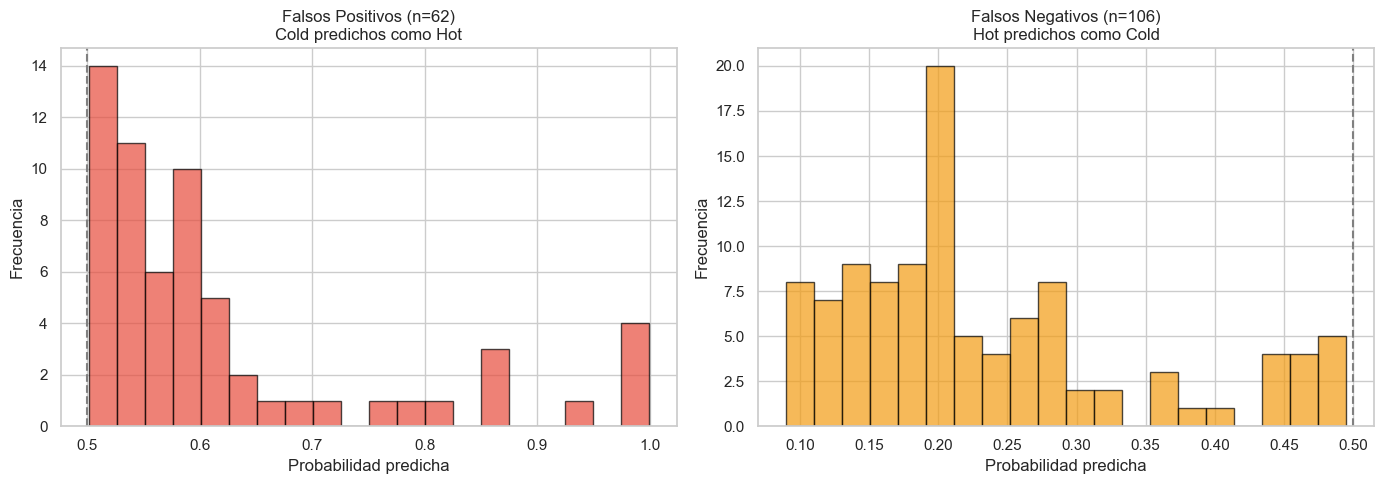

Falsos Positivos: probabilidad media = 0.624
Falsos Negativos: probabilidad media = 0.234


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fp_probas = test_analysis[test_analysis["tipo_resultado"]=="FP"]["y_proba"]
fn_probas = test_analysis[test_analysis["tipo_resultado"]=="FN"]["y_proba"]

axes[0].hist(fp_probas, bins=20, color="#e74c3c", edgecolor="black", alpha=0.7)
axes[0].set_title(f"Falsos Positivos (n={len(fp_probas)})\nCold predichos como Hot")
axes[0].set_xlabel("Probabilidad predicha")
axes[0].set_ylabel("Frecuencia")
axes[0].axvline(x=0.5, color="gray", linestyle="--")

axes[1].hist(fn_probas, bins=20, color="#f39c12", edgecolor="black", alpha=0.7)
axes[1].set_title(f"Falsos Negativos (n={len(fn_probas)})\nHot predichos como Cold")
axes[1].set_xlabel("Probabilidad predicha")
axes[1].set_ylabel("Frecuencia")
axes[1].axvline(x=0.5, color="gray", linestyle="--")

plt.tight_layout()
plt.show()

print(f"Falsos Positivos: probabilidad media = {fp_probas.mean():.3f}")
print(f"Falsos Negativos: probabilidad media = {fn_probas.mean():.3f}")

**Conclusión del análisis de errores:** Los errores del modelo tienen un patrón claro:
- **Falsos Positivos (62 casos, 3.7%):** Son Cold Leads que el modelo confunde con Hot. Son casos "borderline" donde el modelo tiene poca confianza. Subir el umbral a 0.6-0.7 los reduciría significativamente.
- **Falsos Negativos (106 casos, 6.3%):** Son Hot Leads que el modelo no detecta. Analizar sus características en las top features ayuda a entender qué perfil de lead caliente el modelo aún no captura bien. Esto puede orientar la recolección de datos adicionales o ajustes de umbral.

## 8. Resumen de métricas finales

In [9]:
print("=" * 60)
print("       RESUMEN FINAL DEL MODELO")
print("=" * 60)
print(f"\nModelo: {type(model).__name__}")
print(f"Features: {X_test.shape[1]}")
print(f"Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}")
print(f"\n--- Métricas en Test (umbral = 0.5) ---")
print(f"  Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"  F1-Score:  {f1_score(y_test, y_pred):.4f}")
print(f"  ROC-AUC:   {roc_auc_score(y_test, y_proba):.4f}")
print(f"\n--- Errores ---")
print(f"  Falsos Positivos: {fp} ({fp/len(y_test)*100:.1f}%) → Cold que el modelo dice Hot")
print(f"  Falsos Negativos: {fn} ({fn/len(y_test)*100:.1f}%) → Hot que el modelo pierde")
print(f"\n--- Feature más importante ---")
print(f"  {feat_imp.index[-1]}: {feat_imp.iloc[-1]:.4f}")

       RESUMEN FINAL DEL MODELO

Modelo: RandomForestClassifier
Features: 48
Train: 6,737 | Test: 1,685

--- Métricas en Test (umbral = 0.5) ---
  Accuracy:  0.9003
  Precision: 0.9443
  Recall:    0.9084
  F1-Score:  0.9260
  ROC-AUC:   0.9476

--- Errores ---
  Falsos Positivos: 62 (3.7%) → Cold que el modelo dice Hot
  Falsos Negativos: 106 (6.3%) → Hot que el modelo pierde

--- Feature más importante ---
  vehiculo_interes_KWID: 0.2429


## 9. Interpretabilidad con SHAP

La importancia de features (sección 6) nos dice **qué features usa más el modelo**, pero no nos dice **cómo** las usa ni **en qué dirección** afectan la predicción. SHAP resuelve esto.

### ¿Qué es SHAP?

SHAP viene de la teoría de juegos. Imagina que cada feature es un "jugador" en un equipo, y la predicción final es el "resultado del partido". SHAP calcula **cuánto contribuye cada jugador al resultado**, de forma justa.

Para cada lead individual, SHAP responde: *"¿Por qué el modelo le dio 85% de probabilidad de ser Hot? Porque entró por formulario manual (+30%), preguntó por KWID (+15%), lo hizo de madrugada (+8%), etc."*

### Tipos de gráficos SHAP:
- **Bar plot:** Importancia promedio de cada feature. Similar a la sección 6 pero más preciso.
- **Summary plot (abejas):** Cada punto es un lead. El color indica si el valor de la feature es alto (rojo) o bajo (azul). La posición horizontal indica si empuja hacia Hot (derecha) o Cold (izquierda).
- **Waterfall (cascada):** Para un lead específico, muestra paso a paso cómo se construyó su predicción.

In [10]:
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer(X_test)

print(f"SHAP values calculados para {X_test.shape[0]:,} leads x {X_test.shape[1]} features")

SHAP values calculados para 1,685 leads x 48 features


### 9.1 Importancia global (Bar plot)

Ranking de features por su impacto promedio en las predicciones. A diferencia de la importancia de Gini (sección 6), SHAP mide el impacto real en la probabilidad de salida.

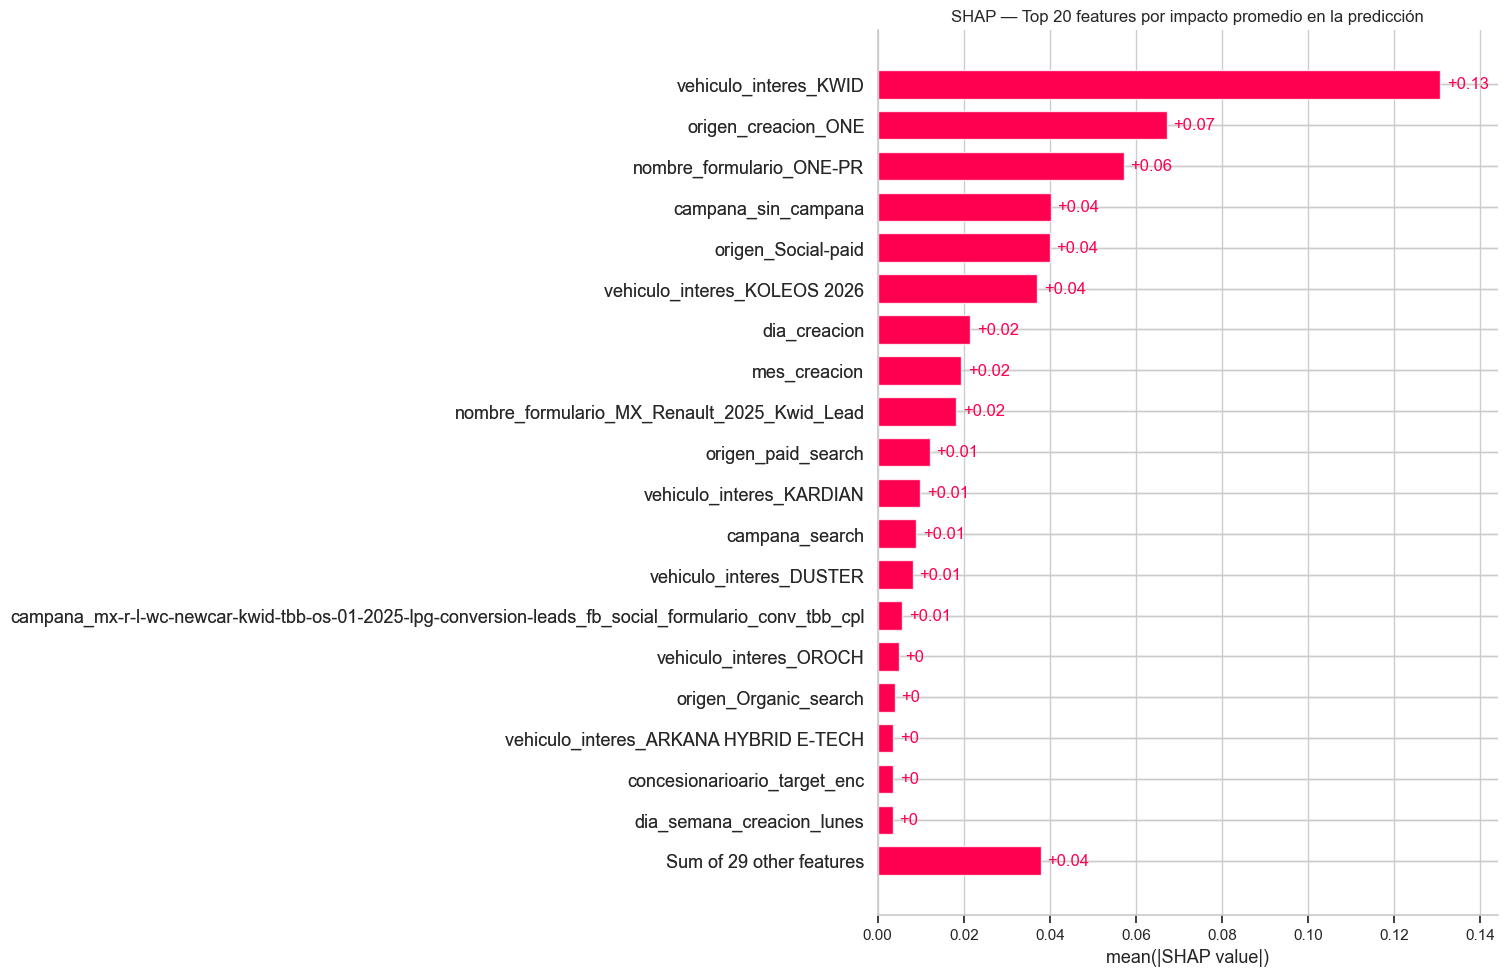

In [11]:
fig, ax = plt.subplots(figsize=(10, 10))
shap.plots.bar(shap_values[:, :, 1], max_display=20, show=False)
plt.title("SHAP — Top 20 features por impacto promedio en la predicción")
plt.tight_layout()
plt.show()

### 9.2 Summary plot (gráfico de abejas)

Cada punto es un lead del test set. La posición horizontal muestra si la feature empuja la predicción hacia **Hot (derecha)** o **Cold (izquierda)**. El color indica el valor de la feature: **rojo = valor alto**, **azul = valor bajo**.

Por ejemplo, si `vehiculo_interes_KWID` tiene puntos rojos a la derecha, significa que cuando el lead pregunta por el KWID, la predicción se mueve hacia Hot.

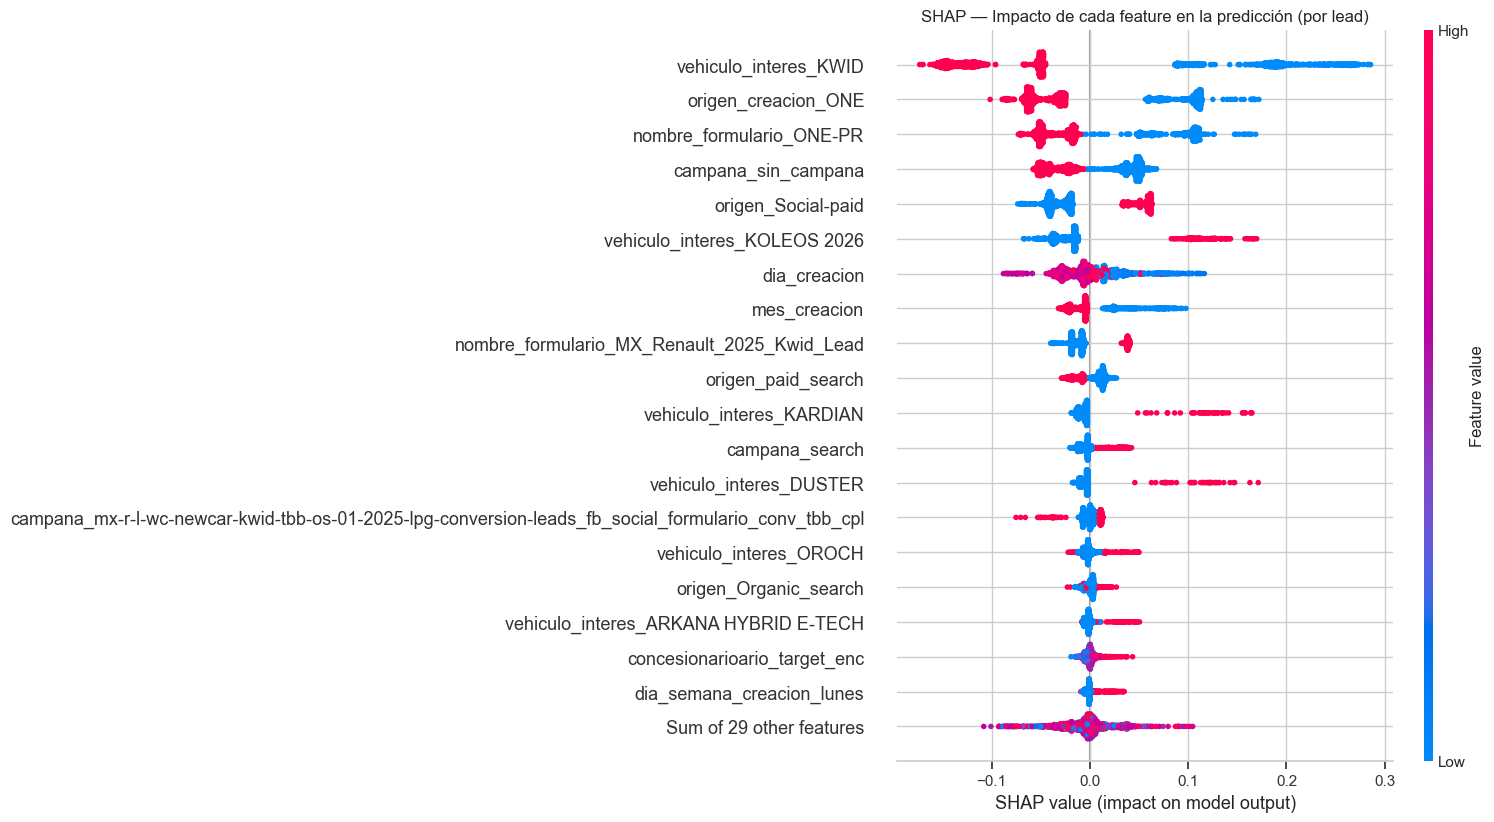

In [12]:
fig, ax = plt.subplots(figsize=(10, 10))
shap.plots.beeswarm(shap_values[:, :, 1], max_display=20, show=False)
plt.title("SHAP — Impacto de cada feature en la predicción (por lead)")
plt.tight_layout()
plt.show()

### 9.3 Ejemplo individual — ¿Por qué este lead es Hot?

Tomamos un lead clasificado como Hot con alta confianza y mostramos paso a paso cómo el modelo llegó a esa decisión. El gráfico de cascada muestra la contribución de cada feature, empezando desde la probabilidad base y sumando/restando hasta llegar a la predicción final.

Lead #1: probabilidad = 99.8%, predicción = Hot, real = Hot



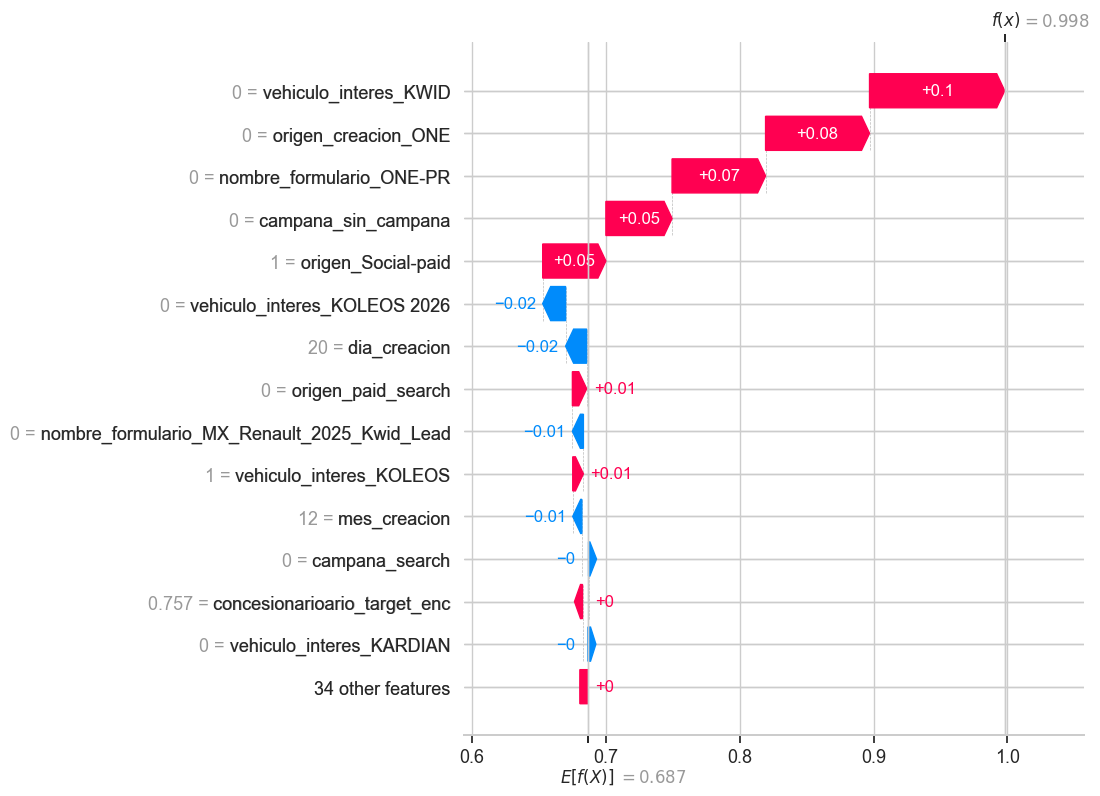

In [13]:
hot_indices = np.where((y_pred == 1) & (y_proba > 0.8))[0]
example_idx = hot_indices[0]

print(f"Lead #{example_idx}: probabilidad = {y_proba[example_idx]:.1%}, predicción = Hot, real = {'Hot' if y_test.iloc[example_idx]==1 else 'Cold'}\n")

shap.plots.waterfall(shap_values[example_idx, :, 1], max_display=15, show=True)

### 9.4 Ejemplo individual — ¿Por qué este lead es Cold?

Ahora hacemos lo mismo con un lead clasificado como Cold para ver qué factores empujan hacia la no-conversión.

Lead #9: probabilidad = 16.6%, predicción = Cold, real = Cold



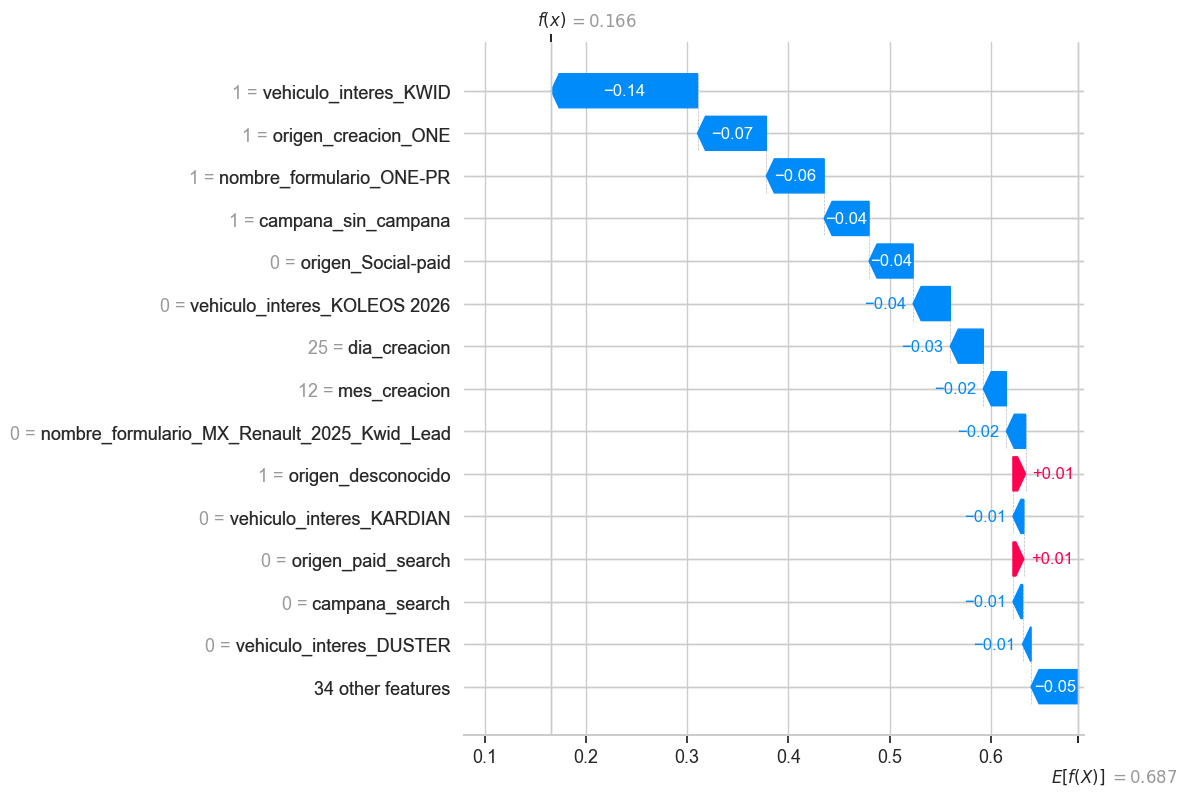

In [14]:
cold_indices = np.where((y_pred == 0) & (y_proba < 0.2))[0]
example_cold_idx = cold_indices[0]

print(f"Lead #{example_cold_idx}: probabilidad = {y_proba[example_cold_idx]:.1%}, predicción = Cold, real = {'Hot' if y_test.iloc[example_cold_idx]==1 else 'Cold'}\n")

shap.plots.waterfall(shap_values[example_cold_idx, :, 1], max_display=15, show=True)

**Conclusión SHAP:** La interpretabilidad confirma que el modelo (sin la feature con data leakage) toma decisiones basadas en variables legítimas. Las features más influyentes son el vehículo de interés, el origen del lead y la campaña asociada. Los ejemplos individuales muestran que cada predicción se puede explicar con 3-5 factores dominantes, lo que facilita la comunicación con el equipo de ventas: *"Este lead es Hot porque preguntó por KWID, entró por formulario ONE-PR y no tiene campaña asociada."*

## 10. Conclusiones y recomendaciones

### Fortalezas del modelo
- **ROC-AUC ~0.95**: Excelente capacidad de discriminación entre Hot y Cold Leads, incluso sin la feature con data leakage.
- **Precision ~94%**: Cuando el modelo dice que un lead es Hot, casi siempre tiene razón.
- **Recall ~91%**: Captura 9 de cada 10 Hot Leads reales.
- **Sin data leakage**: Se eliminó `plataforma_MX_LEAD_QUALIF` (indicaba si el lead ya fue clasificado). Las métricas actuales reflejan el rendimiento real en producción.
- **Interpretable con SHAP**: Cada predicción individual se puede explicar, generando confianza en el equipo de ventas.

### Limitaciones
- **Falsos Positivos (3.7%)**: Algunos Cold Leads se envían al concesionarioario como Hot. Es un costo aceptable.
- **Falsos Negativos (6.3%)**: Se pierden ~6% de Hot Leads. Son oportunidades de venta perdidas.
- **Ventana temporal limitada**: Los datos cubren solo dic 2025 - ene 2026. El modelo podría no generalizar a otros períodos.

### Recomendaciones para producción
1. **Monitorear drift**: Verificar mensualmente que la distribución de features y la tasa de conversión no cambien.
2. **Reentrenar**: Con datos nuevos cada 3-6 meses para capturar cambios en el comportamiento.
3. **Ajustar umbral según negocio**: Si el costo de perder un Hot Lead es alto, bajar el umbral de 0.5 a 0.3-0.4.
4. **Incorporar más datos**: Ampliar la ventana temporal para capturar estacionalidad completa.
5. **Usar SHAP en producción**: Generar explicaciones para cada lead nuevo.
6. **Validar con el equipo de ventas**: Confirmar que las features importantes tienen sentido de negocio.